In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
#| output: false
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de votre package personnalisé de tracé `src.utils_viz`.

### 1. Préparation de l'environnement

In [2]:
#| output: true
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc
from src import utils_viz as uv

uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Style 'light' activé 
Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')
df['duration_min'] = df['duration_ms'] / 60000 
df_feat = df.copy()
df_feat['is_popular'] = (df_feat['popularity'] >= 50).astype(int)  # chanson populaire ou non
df_feat['is_long'] = (df_feat['duration_min'] >= 4).astype(int)    # chanson longue ou non
#| output: false
df_feat.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,is_popular,is_long
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666.0,False,0.676,0.4610,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,1,0
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610.0,False,0.420,0.1660,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,1,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826.0,False,0.438,0.3590,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,1,0
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933.0,False,0.266,0.0596,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,1,0
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853.0,False,0.618,0.4430,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,1,0


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de votre package personnalisé de tracé `src.utils_viz`.

### 3. Tracés et analyses graphiques

#### A. Évolution des tendances dans le temps

Le graphique en barres ci-dessous illustre la domination de 15 genres spécifiques (Pop, Film, R&B) en termes de popularité moyenne. Ce visuel confirme une réalité marché : appartenir à un genre 'mainstream' offre un tremplin algorithmique considérable pour qu'un morceau devienne viral.


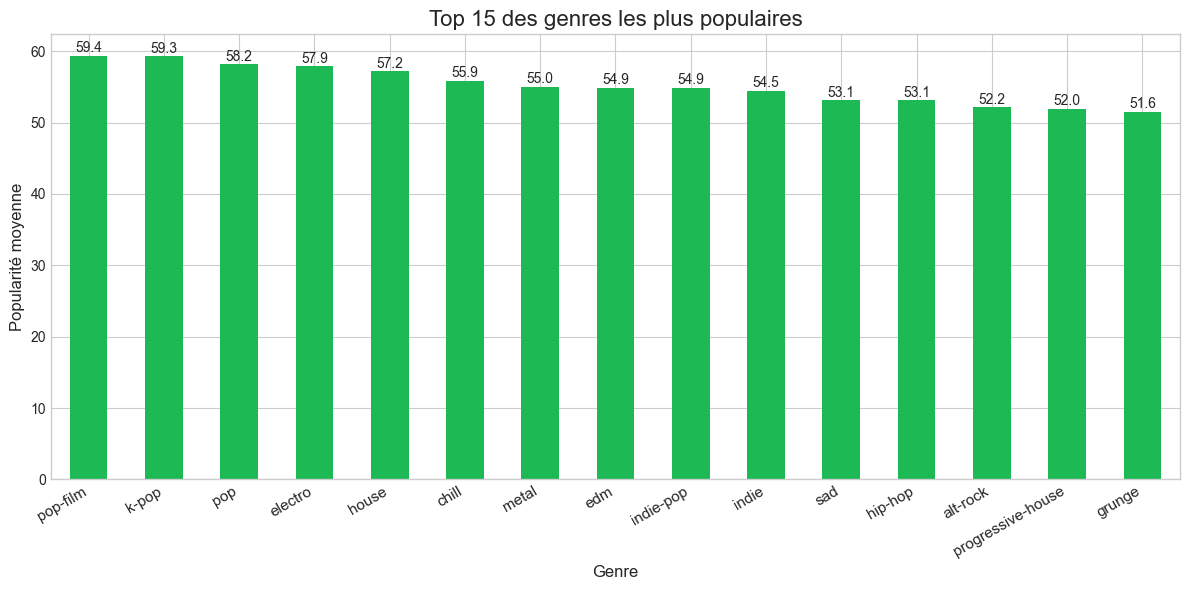

In [4]:
#| output: true
fig, ax = plt.subplots(figsize=(12, 6))

# Garder seulement les 15 genres les plus populaires
top15 = df_feat.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)

top15.plot(kind='bar', color='#1DB954', ax=ax)

ax.set_title("Top 15 des genres les plus populaires", fontsize=16)
ax.set_xlabel("Genre", fontsize=12)
ax.set_ylabel("Popularité moyenne", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)

# Ajouter les valeurs sur chaque barre
for i, v in enumerate(top15):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### B. Carte de chaleur des corrélations

La matrice de corrélation (Heatmap) générée ci-dessous est cruciale. Elle révèle visuellement des liens forts et attendus (comme entre l'énergie et le volume/loudness). En revanche, et c'est le point clé de notre étude : la `popularity` n'affiche aucune corrélation linéaire forte avec la `danceability`.


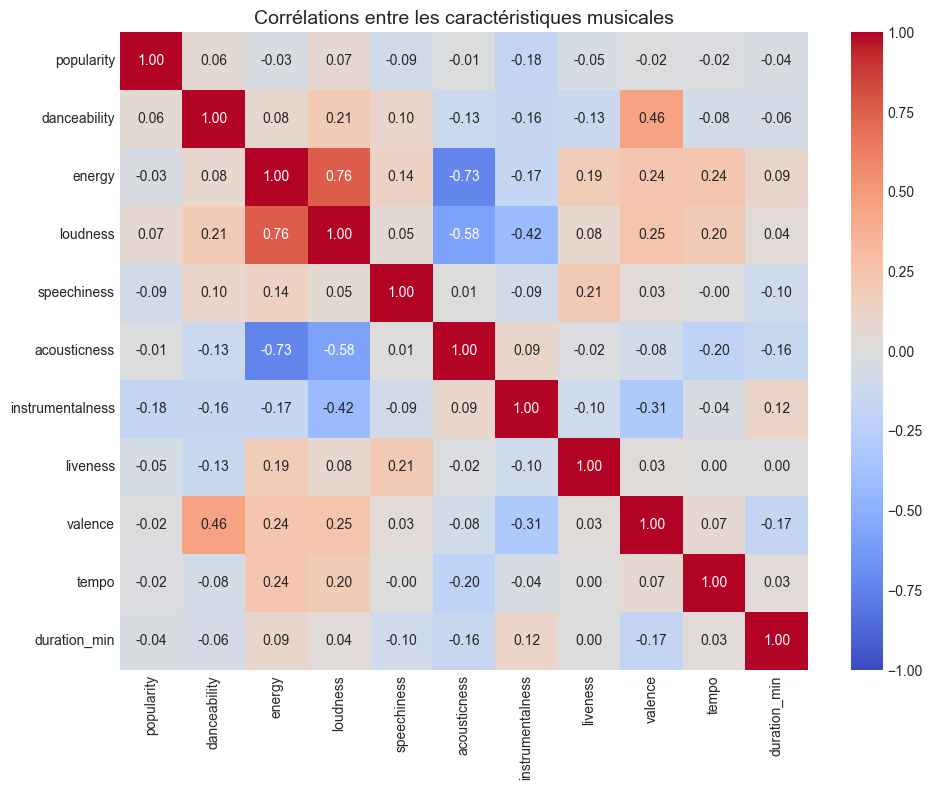

In [5]:
#| output: true
colonnes_correlation = [
    'popularity', 
    'danceability', 
    'energy', 
    'loudness', 
    'speechiness', 
    'acousticness', 
    'instrumentalness', 
    'liveness', 
    'valence', 
    'tempo',
    'duration_min'
]

# Appeler la fonction
uv.plot_correlation_matrix(
    df_feat, 
    colonnes_correlation,
    title="Corrélations entre les caractéristiques musicales"
)
plt.show()

#### C. Nuage de points bivarié

Le nuage de points (Scatter plot) ci-dessous, croisant la dansabilité et la popularité sur le Top 5 des genres, montre une dispersion totale. L'intégration de ce graphique valide visuellement notre hypothèse : un morceau très dansable peut tout à fait avoir une popularité proche de zéro. La dansabilité est un outil pour créer une trend de danse, mais c'est le marketing qui dicte la popularité finale.


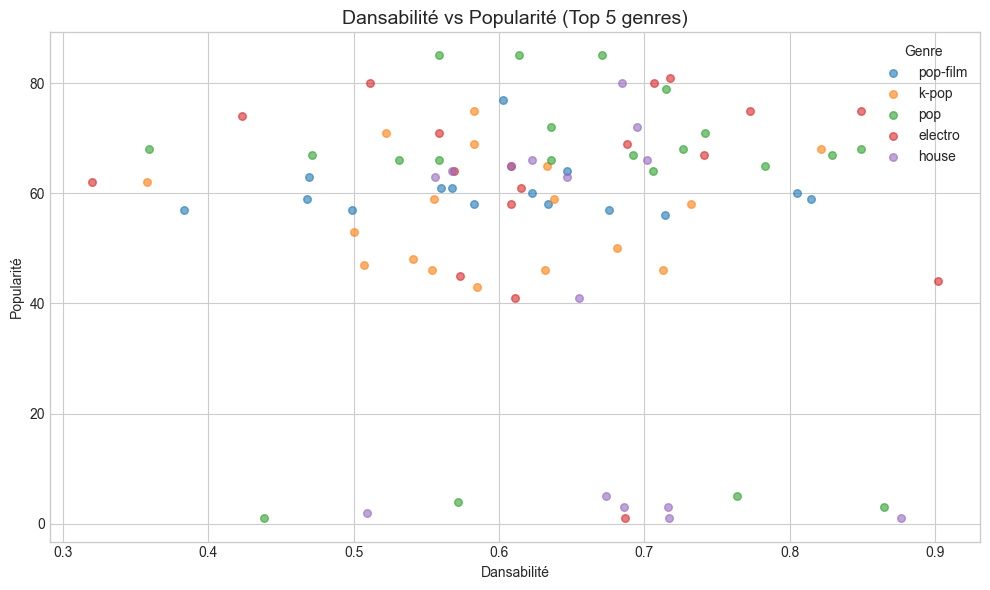

In [6]:
#| output: true
# Nuage de points : danceability vs popularity coloré par genre
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Prendre seulement 2000 chansons au hasard pour que ce soit lisible
df_sample = df_feat.sample(2000, random_state=42)

# Colorer par genre (top 5 seulement)
top5_genres = df_feat.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(5).index

df_sample_top = df_sample[df_sample['track_genre'].isin(top5_genres)]

for genre in top5_genres:
    subset = df_sample_top[df_sample_top['track_genre'] == genre]
    ax.scatter(subset['danceability'], subset['popularity'], 
               label=genre, alpha=0.6, s=30)

ax.set_title("Dansabilité vs Popularité (Top 5 genres)", fontsize=14)
ax.set_xlabel("Dansabilité")
ax.set_ylabel("Popularité")
ax.legend(title="Genre")
plt.tight_layout()
plt.show()